# zagg end to end: ICESat-2 photons to analysis-ready Zarr

[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/englacial/zagg/main?urlpath=lab/tree/notebooks/sponsor_end_to_end.ipynb)

This notebook walks the **complete zagg pipeline** on real public data — NASA's
ICESat-2 ATL03 photon cloud over the NEON [SERC](https://www.neonscience.org/field-sites/serc)
site (Smithsonian Environmental Research Center, Edgewater MD):

1. **Catalog** — query NASA CMR for granule metadata and snapshot it as a
   STAC-geoparquet file (*build once, reuse everywhere*).
2. **Shardmap** — intersect granule footprints with the output grid, once, into a
   work-distribution manifest that carries a strict-AOI cell mask (issue #101).
3. **Two aggregations from that one shardmap** (issue #89): a per-cell
   **t-digest** sketch of photon heights with a morton location channel
   (issue #87), and a per-chunk **gain/bias 128-bin waveform** — both reading
   through the virtual chunk-index seam (issue #160), which persists a
   granule-keyed chunk-manifest cache as a side effect of the first run.
4. **Read-back** — open the Zarr outputs, map the photon density, and check the
   t-digest reconstruction against the binned waveform.

The **companion notebook** [`sponsor_read_only.ipynb`](sponsor_read_only.ipynb)
consumes the published outputs **anonymously** (no credentials at all) and is the
one to hand to anyone who just wants to *read* the products.

**Requirements.** `pip install "zagg[analysis,catalog,viz]"` (zagg ≥ 0.13; the
Binder image already provides it via the repo's `.binder/` environment).
Sections 1–3 run **anywhere, with no credentials** — CMR granule *metadata* is
anonymous. The aggregation runs in section 5 read ATL03 granule *data* and write
to S3, so they need NASA Earthdata Login + AWS credentials (each run cell states
exactly what it needs). The optional `sidecar` index backend additionally uses
`h5coro-hidefix` ≥ 0.2.

## 1. Catalog: CMR → STAC-geoparquet, built once

`CMRSource` speaks directly to NASA's CMR-STAC endpoint — no Earthdata Login is
needed for granule-metadata queries. The result wraps a
[stac-geoparquet](https://github.com/stac-utils/stac-geoparquet) Arrow table
(one row per granule, S3 **and** HTTPS hrefs preserved).

The area of interest is the NEON SERC AOP flight box
(`tests/data/benchmark/AOP_NEON.geojson`) and the temporal window is the full
multi-year benchmark slice `2018-10-13 .. 2025-06-01` — the same AOI + window
the repo's Lambda benchmark matrix pins (`tests/data/benchmark/README.md`).

**Build once, commit the snapshot.** A CMR fetch is cheap here (~60 granules)
but O(20 min) for mission-scale AOIs, so the repo convention (issues #148/#152)
is to snapshot the catalog as geoparquet next to the artifacts that derive from
it, and rebuild only to deliberately re-pin. This notebook writes
`data/cat_serc_atl03_007.parquet`, which is committed with the repo.

In [1]:
import zagg

print(f"zagg {zagg.__version__}")

zagg 0.13.0


In [2]:
from zagg.catalog.sources import CMRSource, Query

AOI_GEOJSON = "../tests/data/benchmark/AOP_NEON.geojson"  # NEON SERC AOP box
START_DATE, END_DATE = "2018-10-13", "2025-06-01"         # benchmark temporal pin

query = Query(
    short_name="ATL03",
    version="007",
    start_date=START_DATE,
    end_date=END_DATE,
    region=AOI_GEOJSON,          # a bbox tuple also works
    provider="NSIDC_CPRD",
)

catalog = CMRSource().fetch(query)
print(f"Fetched {len(catalog)} ATL03 granules for {query.collection} over SERC")

INFO:stac_geoparquet.arrow._api:parse_stac_items_to_arrow start | CPU%: 0.0 | CPU_USER_TIME: 1.239 | RSS(MB):198.09 | USS(MB):148.58


INFO:stac_geoparquet.arrow._batch:Items Length: 59


Fetched 59 ATL03 granules for ATL03_007 over SERC


In [3]:
from pathlib import Path

from zagg.catalog.sources import Catalog

DATA = Path("data")
DATA.mkdir(exist_ok=True)
cat_path = DATA / "cat_serc_atl03_007.parquet"
catalog.to_geoparquet(str(cat_path))

# Round-trip: later runs (and the drift tests) load the committed snapshot
# instead of re-fetching CMR.
catalog = Catalog.from_geoparquet(str(cat_path))
print(f"{cat_path} ({cat_path.stat().st_size / 1024:.0f} KB), "
      f"{len(catalog)} granules on reload")

data/cat_serc_atl03_007.parquet (55 KB), 59 granules on reload


## 2. Shardmap: one manifest, built from the saved catalog

A **ShardMap** maps each populated grid *shard* (the dispatch unit — one worker
per shard) to the granules whose footprints cross it. It is tied to the grid's
**spatial signature only**, so any config that shares the spatial grid can reuse
it — which is exactly what section 5 does with two different aggregations
(issue #89).

The grid comes from the run configs themselves (single source of truth): a
HEALPix nested grid, `parent_order=10` shards (~5 km), `child_order=19` leaf
cells (~10 m), 64 inner Zarr chunks per shard. Both example configs turn on
`output.aoi_mask` (issue #101), so the build also precomputes a compact
per-shard **strict-AOI mask payload**: at write time every output shard gets an
`aoi_mask` boolean cell column — *"package, don't clip"*: edge shards keep
their full photon content, and the AOI selection becomes a read-time filter.

In [4]:
from importlib.resources import files

from zagg.config import load_config
from zagg.grids import from_config

cfg_dir = files("zagg.configs")
cfg_tdigest = load_config(str(cfg_dir / "atl03_tdigest_serc.yaml"))
cfg_gain_bias = load_config(str(cfg_dir / "atl03_gain_bias_serc.yaml"))

grid = from_config(cfg_tdigest)
grid_gb = from_config(cfg_gain_bias)

# The reuse contract (#89): identical spatial signatures -> one shardmap serves both.
assert grid.spatial_signature() == grid_gb.spatial_signature()
grid.spatial_signature()

{'type': 'healpix',
 'indexing_scheme': 'nested',
 'parent_order': 10,
 'child_order': 19,
 'layout': 'fullsphere'}

In [5]:
from zagg.catalog import load_polygon
from zagg.catalog.shardmap import ShardMap

parts = load_polygon(AOI_GEOJSON)   # [(lats, lons)] ring parts of the SERC box

# region drives shard coverage; the strict-AOI mask defaults to the same
# polygon. backend="mortie" is the HEALPix-native intersection engine
# (backend="auto" upgrades to exact-S2 spherely when installed).
shardmap = ShardMap.build(catalog, grid, region=parts, backend="mortie")

print(f"{len(shardmap.shard_keys)} shards, "
      f"{shardmap.metadata['total_pairs']} granule-shard pairs, "
      f"built in {shardmap.metadata['build_wall_s']:.2f}s")
print(f"strict-AOI payload present: {shardmap.aoi_mask is not None}")

9 shards, 326 granule-shard pairs, built in 0.68s
strict-AOI payload present: True


In [6]:
import numpy as np

sm_path = DATA / "sm_serc_healpix_o10.json"
shardmap.to_json(str(sm_path))
print(f"{sm_path} ({sm_path.stat().st_size / 1024:.0f} KB)\n")

# Per-shard granule load + how much of each shard is inside the strict AOI.
# The stored payload is a compact sub-MOC; the grid expands it to a per-cell
# bool over the shard's children — the same expansion the worker does.
print(f"{'shard key':>20}  granules  in-AOI cells (of {len(grid.children(shardmap.shard_keys[0])):,})")
for key, grans, payload in zip(shardmap.shard_keys, shardmap.granules, shardmap.aoi_mask):
    mask = grid.aoi_mask_for_children(np.asarray(payload, dtype=np.uint64), grid.children(key))
    print(f"{key:>20}  {len(grans):8d}  {int(mask.sum()):12,}")

data/sm_serc_healpix_o10.json (232 KB)

           shard key  granules  in-AOI cells (of 262,144)
 5347394537339748362        44         2,703
 5347395636851376138        30        50,638
 5347396736363003914        28       130,789
 5347397835874631690        48       221,073
 5347398935386259466        33       190,861
 5347404432944398346        44        38,613
 5347405532456026122        50         8,210


 5347408830990909450        22            96
 5347411030014165002        27         5,707


### Visualize the shardmap

Nine order-10 HEALPix shards cover the ~10 km SERC box. The static render below
colors each shard by its granule count over the strict-AOI polygon (red); the
following cell opens the same map interactively (`zagg.viz`, ipyleaflet) with
the granule footprints as a toggleable layer, exactly as in
[`shardmap_viewer.ipynb`](shardmap_viewer.ipynb).

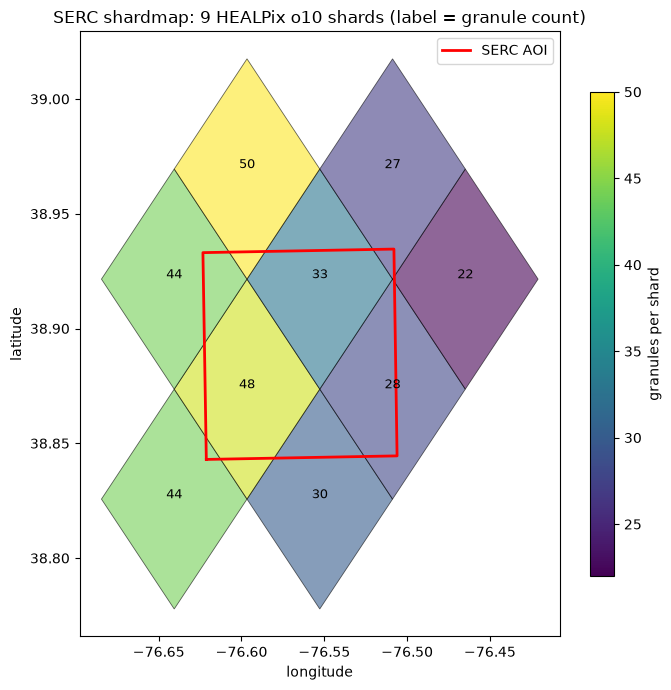

In [7]:
import matplotlib.pyplot as plt
from matplotlib import colormaps
from matplotlib.colors import Normalize

fig, ax = plt.subplots(figsize=(7, 7))
counts = [len(g) for g in shardmap.granules]
norm = Normalize(vmin=min(counts), vmax=max(counts))
cmap = colormaps["viridis"]

for key, n in zip(shardmap.shard_keys, counts):
    poly = grid.shard_footprint(key)          # WGS84 (lon, lat), lon in 0..360
    lon, lat = np.asarray(poly.exterior.xy[0]), np.asarray(poly.exterior.xy[1])
    lon = np.where(lon > 180, lon - 360, lon)
    ax.fill(lon, lat, color=cmap(norm(n)), alpha=0.6, edgecolor="k", lw=0.6)
    ax.annotate(str(n), (lon.mean(), lat.mean()), ha="center", fontsize=9)

for lats, lons in parts:                       # the strict-AOI polygon
    ax.plot(np.asarray(lons), np.asarray(lats), "r-", lw=2, label="SERC AOI")

sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
plt.colorbar(sm, ax=ax, label="granules per shard", shrink=0.8)
ax.set_xlabel("longitude")
ax.set_ylabel("latitude")
ax.set_title("SERC shardmap: 9 HEALPix o10 shards (label = granule count)")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

In [8]:
from zagg.viz import show_shardmap

# Interactive viewer (mid-latitude AOI -> Web Mercator). Granule footprints and
# shard outlines are separate toggleable layers.
m = show_shardmap(str(sm_path), catalog=str(cat_path), zoom=11)
print("display CRS:", m.crs["name"])
m

display CRS: EPSG3857


Map(center=[38.89764435814321, -76.552734375], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoo…

## 3. The two run configs

Both configs ship with zagg (`zagg/configs/atl03_tdigest_serc.yaml`,
`zagg/configs/atl03_gain_bias_serc.yaml`). They share the read plan (planned
segment→photon IO, issue #43), the confidence filter, the output grid — and
therefore the shardmap — and differ only in the `aggregation` block:

| | `atl03_tdigest_serc` | `atl03_gain_bias_serc` |
|---|---|---|
| per-cell output | t-digest sketch of `h_ph` (ragged CSR, ~256 centroids) | 128-bin waveform counts (`uint32[128]`) |
| per-chunk output | — | `offset_h` + `gain_h` (the scale/offset frame) |
| location channel | **morton locations per centroid** (issue #87) | — |
| quantiles at read time | any (p5/median/p95/...) | binned only |

Three newer features to notice:

- **`output.aoi_mask: true`** (issue #101) — every output shard carries a
  per-cell in-AOI boolean; nothing is clipped at write time.
- **`data_source.index`** (issue #160) — the read path goes through a pluggable
  **virtual chunk-index**. The t-digest config uses the `inline` backend with
  `write_back: true`: each granule's HDF5 chunk map is built on the fly
  (~1 GET + ~20 ms) and **persisted** as a granule-keyed parquet manifest under
  the canonical sidecar prefix `zagg-index/<product>/<version>/`. That cache is
  grid- and AOI-independent — built once per granule, reusable by every future
  config.
- **`location: leaf_id`** on the t-digest field (issue #87) — each centroid also
  stores the deepest HEALPix cell (packed order-29 morton word) enclosing the
  photons merged into it, as a lossless `uint64` companion CSR array.

With `h5coro-hidefix` ≥ 0.2 installed, a later run consumes the manifests
directly by swapping the index block to the plugin-provided `sidecar` backend:

```yaml
data_source:
  index:
    backend: sidecar                                    # from h5coro-hidefix
    store: s3://sliderule-public-cors/zagg-index/ATL03/007
    on_miss: fallback     # hierarchical read for granules not yet cached
```

In [9]:
import yaml

print("tdigest  index block:", cfg_tdigest.data_source["index"])
print("gain_bias index block:", cfg_gain_bias.data_source["index"])
print()
print("located t-digest field:")
print(yaml.dump({"h_tdigest": cfg_tdigest.aggregation["variables"]["h_tdigest"]},
                default_flow_style=False))

tdigest  index block: {'backend': 'inline', 'write_back': True, 'store': 's3://sliderule-public-cors/zagg-index/ATL03/007'}
gain_bias index block: {'backend': 'inline'}

located t-digest field:
h_tdigest:
  dtype: float32
  fill_value: 0
  function: zagg.stats.tdigest.build_tdigest
  inner_shape:
  - 2
  kind: ragged
  location: leaf_id
  params:
    delta: 256
  source: h_ph

